In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/world-happiness-report/world_happiness_report.csv


## Title: Global Happiness Index: Insights from the World Happiness Report

#### Description: Explore the key findings from the World Happiness Report, a comprehensive study ranking countries based on factors like well-being, economic stability, social support, and life expectancy. Discover what makes nations happier and the trends shaping global happiness.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/world-happiness-report/world_happiness_report.csv')

In [3]:
df.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,...,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,...,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,...,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,...,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,...,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55


In [4]:
df.tail()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
3995,South Africa,2005,7.43,1504.73,0.17,50.20,0.99,0.27,0.69,2.16,...,0.96,83.55,25.65,6.69,66.67,8.18,91.14,28.88,0.07,85.95
3996,India,2018,5.71,50182.85,0.96,67.67,0.84,0.43,0.88,7.19,...,0.70,89.03,41.70,9.57,82.84,8.42,83.05,55.50,0.74,91.96
3997,South Africa,2021,6.23,6158.53,0.22,67.08,0.42,0.19,0.10,2.25,...,0.59,67.74,24.58,8.02,81.29,6.97,72.08,61.16,0.29,89.19
3998,Brazil,2014,5.73,38214.54,0.46,55.72,0.74,0.28,0.46,8.74,...,0.21,62.73,56.21,5.60,30.44,4.67,87.21,49.50,0.11,85.44
3999,UK,2016,3.26,30740.42,0.11,67.31,0.67,0.23,0.23,3.13,...,0.15,77.93,29.20,8.23,49.73,4.30,92.22,56.39,0.10,51.85


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4000 non-null   object 
 1   Year                       4000 non-null   int64  
 2   Happiness_Score            4000 non-null   float64
 3   GDP_per_Capita             4000 non-null   float64
 4   Social_Support             4000 non-null   float64
 5   Healthy_Life_Expectancy    4000 non-null   float64
 6   Freedom                    4000 non-null   float64
 7   Generosity                 4000 non-null   float64
 8   Corruption_Perception      4000 non-null   float64
 9   Unemployment_Rate          4000 non-null   float64
 10  Education_Index            4000 non-null   float64
 11  Population                 4000 non-null   int64  
 12  Urbanization_Rate          4000 non-null   float64
 13  Life_Satisfaction          4000 non-null   float

In [6]:
df.describe()

,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2014.670750,5.455005,30482.009953,0.505860,67.917605,0.502722,0.143960,0.498920,10.966748,0.750385,...,0.502812,69.976853,40.002648,6.009270,65.176380,5.987325,67.586327,45.526322,0.494105,74.021450
std,5.724075,1.427370,17216.122032,0.286202,10.172091,0.285219,0.200088,0.288866,5.210712,0.144819,...,0.289186,17.128536,11.634987,2.291172,19.981357,1.725363,15.769023,20.300069,0.293191,13.906888
min,2005.000000,3.000000,1009.310000,0.000000,50.000000,0.000000,-0.200000,0.000000,2.000000,0.500000,...,0.000000,40.000000,20.010000,2.010000,30.010000,3.000000,40.010000,10.030000,0.000000,50.000000
25%,2010.000000,4.237500,15425.125000,0.260000,59.177500,0.260000,-0.030000,0.240000,6.450000,0.630000,...,0.260000,55.580000,29.865000,4.040000,48.170000,4.460000,53.910000,27.840000,0.230000,61.867500
50%,2015.000000,5.430000,29991.255000,0.510000,68.015000,0.500000,0.140000,0.500000,10.995000,0.750000,...,0.500000,69.650000,40.015000,6.070000,64.755000,6.020000,68.015000,45.760000,0.490000,74.475000
75%,2020.000000,6.662500,45763.085000,0.750000,76.690000,0.750000,0.310000,0.742500,15.450000,0.880000,...,0.760000,84.582500,50.187500,8.010000,82.652500,7.490000,81.332500,63.197500,0.760000,85.912500
max,2024.000000,8.000000,59980.720000,1.000000,85.000000,1.000000,0.500000,1.000000,19.990000,1.000000,...,1.000000,100.000000,59.970000,10.000000,99.990000,9.000000,94.990000,79.990000,1.000000,98.000000


In [7]:
df.isnull().sum()

Country                      0
Year                         0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Corruption_Perception        0
Unemployment_Rate            0
Education_Index              0
Population                   0
Urbanization_Rate            0
Life_Satisfaction            0
Public_Trust                 0
Mental_Health_Index          0
Income_Inequality            0
Public_Health_Expenditure    0
Climate_Index                0
Work_Life_Balance            0
Internet_Access              0
Crime_Rate                   0
Political_Stability          0
Employment_Rate              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of            Country  Year  Happiness_Score  GDP_per_Capita  Social_Support  \
0            China  2022             4.39        44984.68            0.53   
1               UK  2015             5.49        30814.59            0.93   
2           Brazil  2009             4.65        39214.84            0.03   
3           France  2019             5.20        30655.75            0.77   
4            China  2022             7.28        30016.87            0.05   
...            ...   ...              ...             ...             ...   
3995  South Africa  2005             7.43         1504.73            0.17   
3996         India  2018             5.71        50182.85            0.96   
3997  South Africa  2021             6.23         6158.53            0.22   
3998        Brazil  2014             5.73        38214.54            0.46   
3999            UK  2016             3.26        30740.42            0.11   

      Healthy_Life_Expectancy  Freedom  Gen

In [10]:
df.dtypes

Country                       object
Year                           int64
Happiness_Score              float64
GDP_per_Capita               float64
Social_Support               float64
Healthy_Life_Expectancy      float64
Freedom                      float64
Generosity                   float64
Corruption_Perception        float64
Unemployment_Rate            float64
Education_Index              float64
Population                     int64
Urbanization_Rate            float64
Life_Satisfaction            float64
Public_Trust                 float64
Mental_Health_Index          float64
Income_Inequality            float64
Public_Health_Expenditure    float64
Climate_Index                float64
Work_Life_Balance            float64
Internet_Access              float64
Crime_Rate                   float64
Political_Stability          float64
Employment_Rate              float64
dtype: object

In [11]:
df.shape

(4000, 24)

In [12]:
df.columns

Index(['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita',
       'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity',
       'Corruption_Perception', 'Unemployment_Rate', 'Education_Index',
       'Population', 'Urbanization_Rate', 'Life_Satisfaction', 'Public_Trust',
       'Mental_Health_Index', 'Income_Inequality', 'Public_Health_Expenditure',
       'Climate_Index', 'Work_Life_Balance', 'Internet_Access', 'Crime_Rate',
       'Political_Stability', 'Employment_Rate'],
      dtype='object')

## Data visulizations

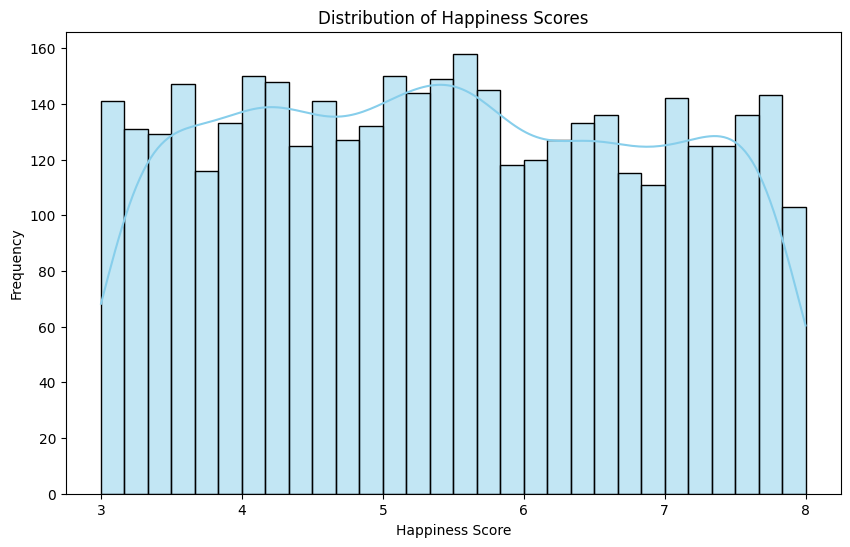

In [13]:
# 1. Happiness Score Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Happiness_Score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

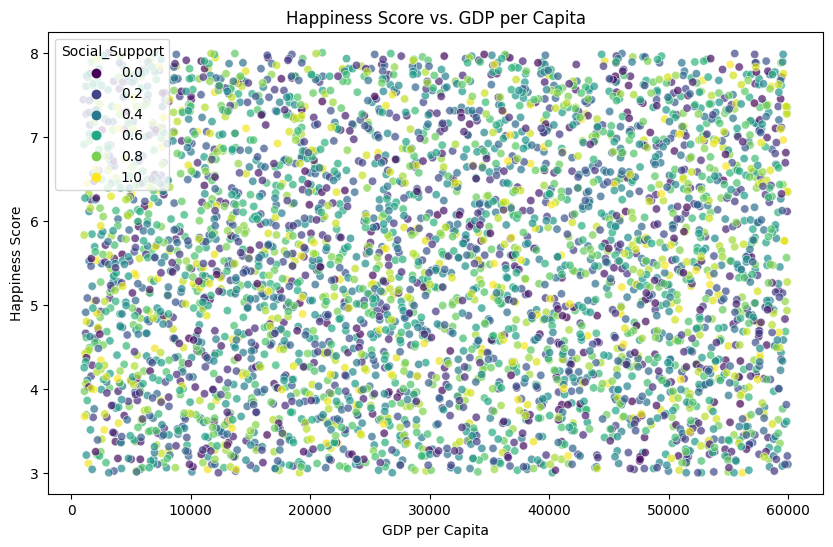

In [14]:
# 2. Happiness Score vs. GDP per Capita
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP_per_Capita', y='Happiness_Score', hue='Social_Support', palette='viridis', alpha=0.7)
plt.title('Happiness Score vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

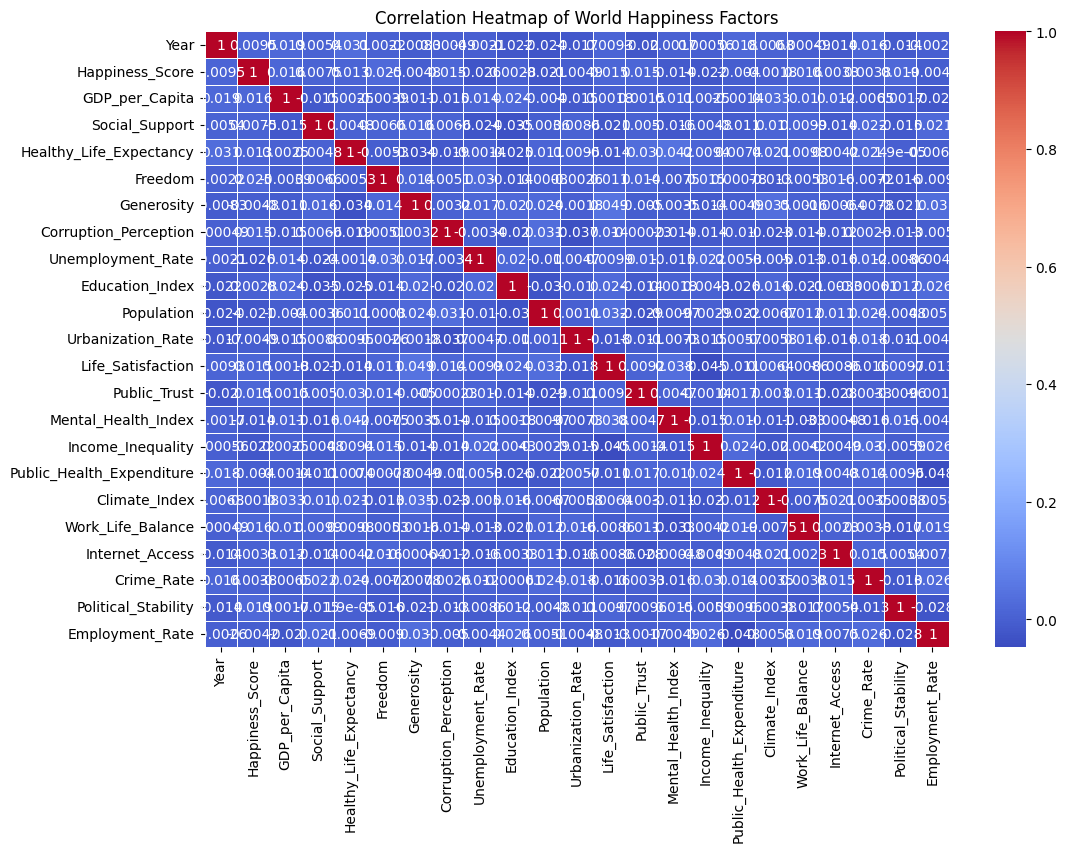

In [15]:
# 3. Correlation Heatmap (Only Numeric Columns)
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of World Happiness Factors')
plt.show()

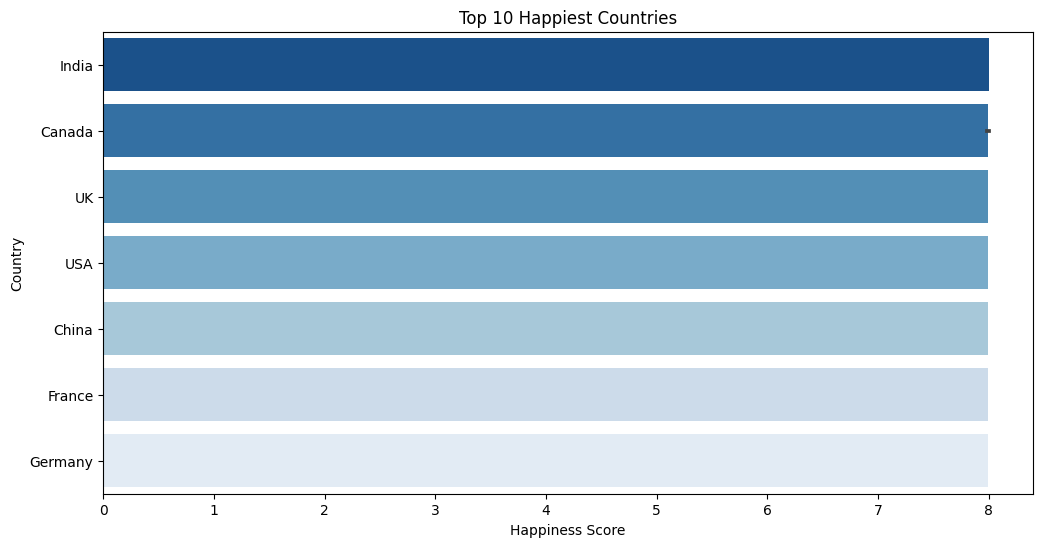

In [16]:
# 4. Top 10 Happiest and Least Happy Countries
happiest = df.nlargest(10, 'Happiness_Score')
least_happy = df.nsmallest(10, 'Happiness_Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=happiest, x='Happiness_Score', y='Country', palette='Blues_r')
plt.title('Top 10 Happiest Countries')
plt.xlabel('Happiness Score')
plt.show()

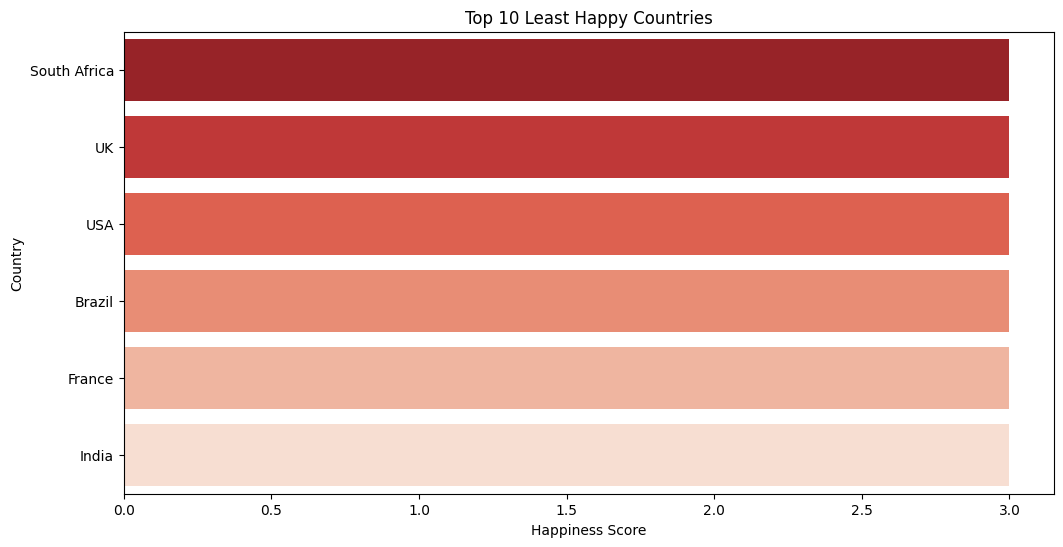

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(data=least_happy, x='Happiness_Score', y='Country', palette='Reds_r')
plt.title('Top 10 Least Happy Countries')
plt.xlabel('Happiness Score')
plt.show()

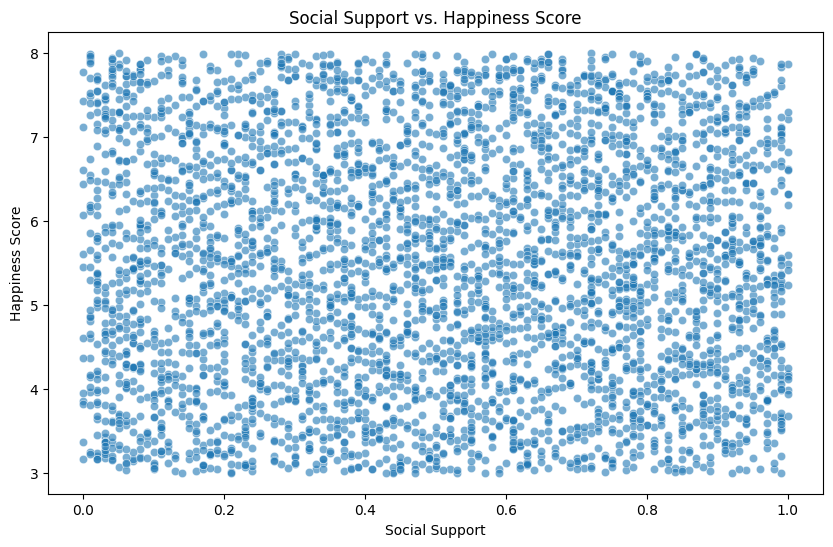

In [18]:
# 5. Impact of Social Support on Happiness
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Social_Support', y='Happiness_Score', alpha=0.6)
plt.title('Social Support vs. Happiness Score')
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.show()

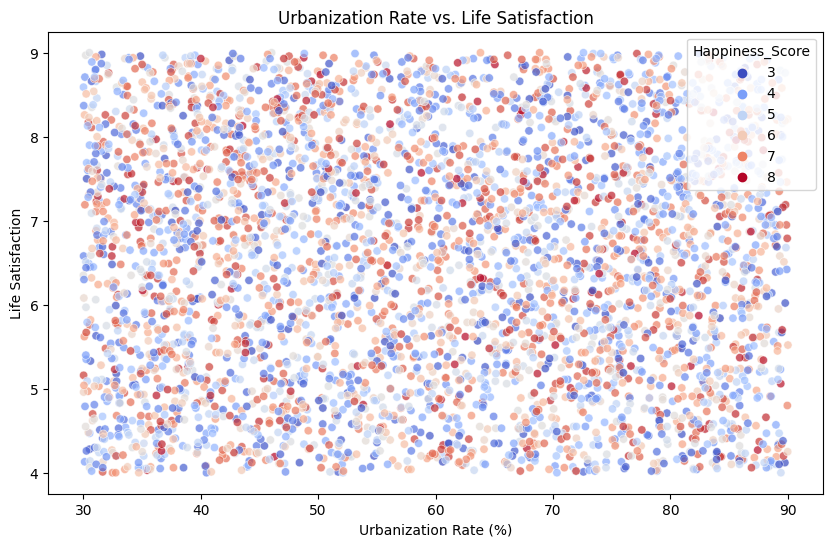

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Urbanization_Rate', y='Life_Satisfaction', hue='Happiness_Score', palette='coolwarm', alpha=0.7)
plt.title('Urbanization Rate vs. Life Satisfaction')
plt.xlabel('Urbanization Rate (%)')
plt.ylabel('Life Satisfaction')
plt.show()

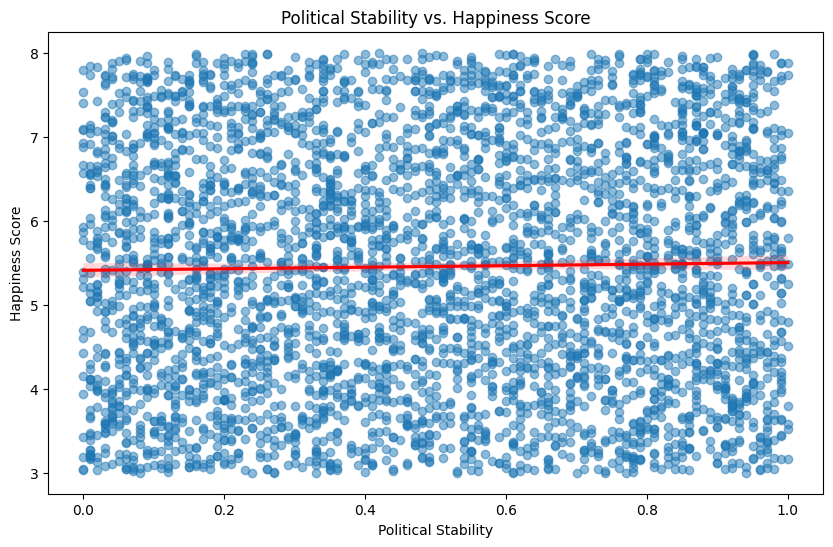

In [20]:
# 7. Political Stability vs. Happiness Score
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Political_Stability', y='Happiness_Score', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Political Stability vs. Happiness Score')
plt.xlabel('Political Stability')
plt.ylabel('Happiness Score')
plt.show()

## Preditive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [22]:
# Encode categorical column 'Country'
label_encoder = LabelEncoder()
df['Country'] = label_encoder.fit_transform(df['Country'])

In [23]:
# Selecting features and target variable
X = df.drop(columns=['Happiness_Score'])
y = df['Happiness_Score']

In [24]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# List of models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

In [27]:
# Training and evaluating models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = r2_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = accuracy

# Display results
for model, acc in results.items():
    print(f"{model}: {acc:.2f}% accuracy")

Linear Regression: -0.98% accuracy
Random Forest: -1.37% accuracy
Support Vector Regression: -14.01% accuracy
K-Nearest Neighbors: -17.31% accuracy
Decision Tree: -117.91% accuracy


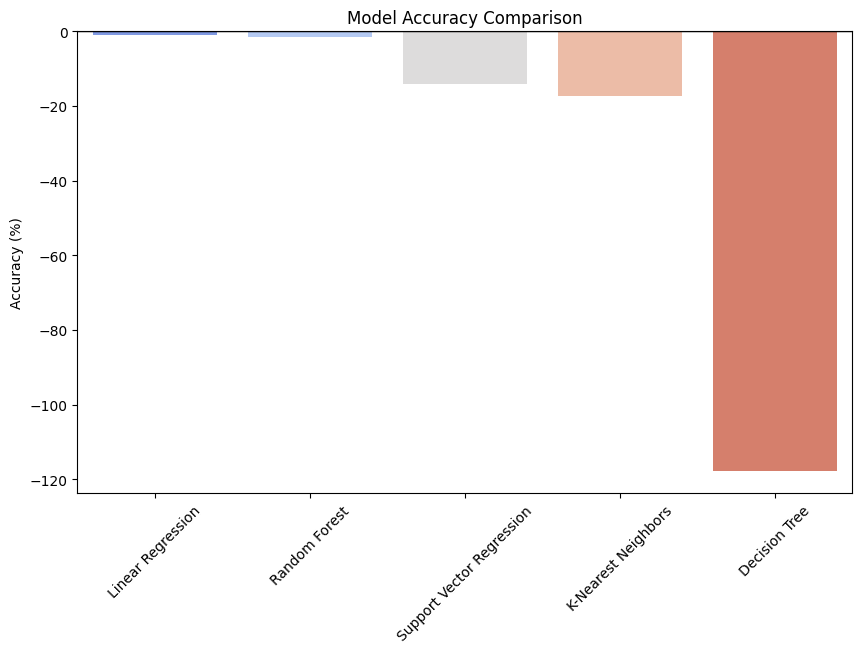

In [28]:
# Plot accuracy in a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.show()

## Thank you..!!!pls upvote!!!